In [1]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import numpy as np

# Load the YOLO model
yolo_model = YOLO("yolo11x.pt", task="detect")

# Choose which patch to apply
patch_type = "softmax"  # or "sigmoid"

# Apply the selected patch
if patch_type == "sigmoid":
    import yolo_patch_sigmoid
elif patch_type == "softmax":
    import yolo_patch_softmax

# Image path
image_path = "photo.jpg"

In [2]:
def parse_detection_results(results):
    """
    Extract detection outputs from YOLO-like model results.

    Args:
        results: List of detection results for ONE IMAGE (e.g., from Ultralytics YOLOv8).

    Returns:
        tuple: (xyxy, conf, cls, prob_vectors, names)
            - xyxy: ndarray of shape (N, 4), bounding boxes in [x1, y1, x2, y2] format
            - conf: ndarray of shape (N,), confidence scores
            - cls: ndarray of shape (N,), class IDs
            - prob_vectors: ndarray of shape (N, num_classes), per-class probabilities
            - names: list or dict of class names
            - num_detections: int, number of detections
    """
    result = results[0]  # One image, one result

    xyxy = result.boxes.xyxy.cpu().numpy()         # (N, 4)
    conf = result.boxes.conf.cpu().numpy()         # (N,)
    cls = result.boxes.cls.cpu().numpy()           # (N,)
    prob_vectors = result.boxes.data[:, 6:].cpu().numpy()  # (N, num_classes)
    names = result.names                           # class names
    num_detections = len(xyxy)                    # number of detections

    return xyxy, conf, cls, prob_vectors, names, num_detections


In [3]:
results = yolo_model.predict(source=image_path, device='cuda:0', conf=0.30, iou=0.40, verbose=False, max_det=10)
xyxy, conf, cls, prob_vectors, names, num_detections = parse_detection_results(results)

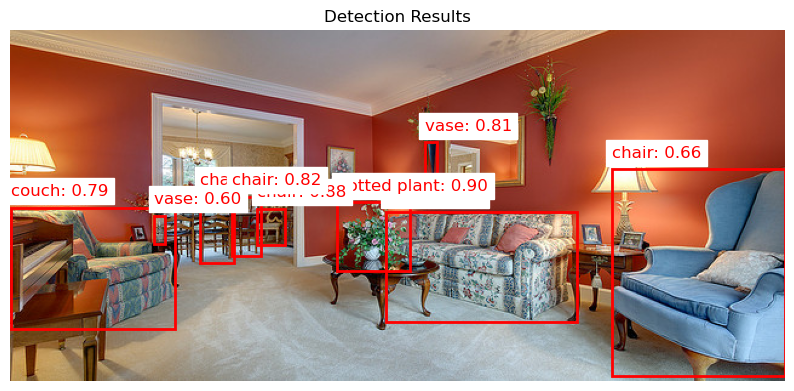

In [4]:
# Load the image
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Plot the image and overlay bounding boxes
plt.figure(figsize=(10, 10))
plt.imshow(image)

for box, class_id, confidence in zip(xyxy, cls, conf.flatten()):
	x1, y1, x2, y2 = box
	label = f"{names[class_id]}: {confidence:.2f}"
	plt.gca().add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1, edgecolor='red', linewidth=2, fill=False))
	plt.text(x1, y1 - 10, label, color='red', fontsize=12, backgroundcolor='white')

plt.axis('off')
plt.title("Detection Results")
plt.show()

In [5]:
# Print the results
print(f"Number of detections: {num_detections}")
print("Bounding boxes (xyxy):", xyxy)
print("Confidence scores:", conf)
print("Class IDs:", cls)


Number of detections: 9
Bounding boxes (xyxy): [[     310.31       149.9      467.38      240.41]
 [     156.48      137.21      184.31      191.87]
 [     269.74      141.99      329.62      198.36]
 [     203.59      147.44      226.25      176.88]
 [     182.98      137.29      207.07      186.39]
 [     341.86      92.534      351.76       122.3]
 [   0.033295       146.5      135.85      246.97]
 [      496.4      114.82       639.7      285.15]
 [     118.76      153.09      127.68      175.98]]
Confidence scores: [[    0.96256]
 [    0.92815]
 [    0.90432]
 [    0.87773]
 [    0.82227]
 [    0.81299]
 [    0.78619]
 [    0.66388]
 [    0.60047]]
Class IDs: [57 56 58 56 56 75 57 56 75]


In [6]:
for prob_vector in prob_vectors:
    print("\nSum of probabilities: {:.3f}".format(prob_vector.sum()), end=' ')
    print("\t1Max probability: {:.3f}".format(prob_vector.max()), end=' ')
    print("\tClass with max probability:", prob_vector.argmax(), "->", names[prob_vector.argmax()])
    print("\t\t\t\t2Max probability: {:.3f}".format(prob_vector[np.argsort(prob_vector)[-2]]), end=' ')
    print("\tClass with second max probability:", np.argsort(prob_vector)[-2], "->", names[np.argsort(prob_vector)[-2]])
    print("\t\t\t\t3Max probability: {:.3f}".format(prob_vector[np.argsort(prob_vector)[-3]]), end=' ')
    print("\tClass with third max probability:", np.argsort(prob_vector)[-3], "->", names[np.argsort(prob_vector)[-3]])
    print("\t\t\t\t4Max probability: {:.3f}".format(prob_vector[np.argsort(prob_vector)[-4]]), end=' ')
    print("\tClass with fourth max probability:", np.argsort(prob_vector)[-4], "->", names[np.argsort(prob_vector)[-4]])
    print("\t\t\t\t5Max probability: {:.3f}".format(prob_vector[np.argsort(prob_vector)[-5]]), end=' ') 
    print("\tClass with fifth max probability:", np.argsort(prob_vector)[-5], "->", names[np.argsort(prob_vector)[-5]])


Sum of probabilities: 1.000 	1Max probability: 0.963 	Class with max probability: 57 -> couch
				2Max probability: 0.003 	Class with second max probability: 56 -> chair
				3Max probability: 0.002 	Class with third max probability: 59 -> bed
				4Max probability: 0.001 	Class with fourth max probability: 47 -> apple
				5Max probability: 0.001 	Class with fifth max probability: 52 -> hot dog

Sum of probabilities: 1.000 	1Max probability: 0.928 	Class with max probability: 56 -> chair
				2Max probability: 0.009 	Class with second max probability: 60 -> dining table
				3Max probability: 0.003 	Class with third max probability: 57 -> couch
				4Max probability: 0.003 	Class with fourth max probability: 13 -> bench
				5Max probability: 0.003 	Class with fifth max probability: 40 -> wine glass

Sum of probabilities: 1.000 	1Max probability: 0.904 	Class with max probability: 58 -> potted plant
				2Max probability: 0.007 	Class with second max probability: 75 -> vase
				3Max probabil

### Softmax results 
Sum of probabilities: 1.000 	Max probability: 1.000 	Class with max probability: 57 -> couch
Sum of probabilities: 1.000 	Max probability: 1.000 	Class with max probability: 56 -> chair
Sum of probabilities: 1.000 	Max probability: 1.000 	Class with max probability: 58 -> potted plant
Sum of probabilities: 1.000 	Max probability: 1.000 	Class with max probability: 56 -> chair
Sum of probabilities: 1.000 	Max probability: 0.998 	Class with max probability: 75 -> vase
Sum of probabilities: 1.000 	Max probability: 0.995 	Class with max probability: 56 -> chair
Sum of probabilities: 1.000 	Max probability: 0.975 	Class with max probability: 75 -> vase
Sum of probabilities: 1.000 	Max probability: 0.971 	Class with max probability: 57 -> couch
Sum of probabilities: 1.000 	Max probability: 0.868 	Class with max probability: 56 -> chair

### Sigmoid results
Sum of probabilities: 1.000 	Max probability: 1.000 	Class with max probability: 57 -> couch
Sum of probabilities: 1.000 	Max probability: 1.000 	Class with max probability: 58 -> potted plant
Sum of probabilities: 1.000 	Max probability: 0.999 	Class with max probability: 56 -> chair
Sum of probabilities: 1.000 	Max probability: 0.999 	Class with max probability: 56 -> chair
Sum of probabilities: 1.000 	Max probability: 0.998 	Class with max probability: 75 -> vase
Sum of probabilities: 1.000 	Max probability: 0.991 	Class with max probability: 56 -> chair
Sum of probabilities: 1.000 	Max probability: 0.962 	Class with max probability: 75 -> vase
Sum of probabilities: 1.000 	Max probability: 0.914 	Class with max probability: 57 -> couch
Sum of probabilities: 1.000 	Max probability: 0.783 	Class with max probability: 56 -> chair